In [194]:
import pandas as pd
import joblib
import numpy as np
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path.cwd().parent
DATABASE_DIR = BASE_DIR / "app" / "data" / "cleaned" / "data_sales_cleaned.parquet"
DATABASE_SQL = BASE_DIR / "app" / "data" / "cleaned" / "sql_supermarket.parquet"
MODELS_DIR = BASE_DIR / "Models"
SALES_MODEL_FILES = [
    MODELS_DIR / "model_LinearRegression.pkl",
    MODELS_DIR / "model_RandomForestRegressor.pkl",
    MODELS_DIR / "model_XGBRegressor.pkl",
]

## Load database

In [195]:
pd.set_option('display.max_columns', None)
df = pd.read_parquet(DATABASE_SQL)
df

,id,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,1,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,0.26
1,2,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,0.30
2,3,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,0.45
3,4,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,48200.0,High,2011,150000.0,-0.58
4,5,CA-2011-1510,2011-02-01,2011-06-01,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,TEC-OKI-10002750,Technology,Machines,"Okidata Inkjet, Wireless",3140000.0,1,0.0,31200.0,241000.0,Medium,2011,3140000.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25030,25031,CA-2014-115427,2014-12-12,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,210000.0,2,0.2,64750.0,20600.0,Medium,2014,105000.0,0.31
25031,25032,UP-2014-4410,2014-12-12,2015-04-01,Standard Class,Guy Thornton,Consumer,Zaporizhzhya,Ukraine,EMEA,EMEA,OFF-AVE-10003558,Office Supplies,Labels,"Avery Round Labels, Alphabetical",280000.0,4,0.0,61200.0,17000.0,Medium,2014,70000.0,0.22
25032,25033,MX-2014-108574,2014-12-12,2015-04-01,Standard Class,Julia Barnett,Home Office,Tamaulipas,Mexico,LATAM,North,OFF-LA-10004969,Office Supplies,Labels,"Novimex Legal Exhibit Labels, Adjustable",170000.0,3,0.0,6600.0,13200.0,Medium,2014,56700.0,0.04
25033,25034,MO-2014-2560,2014-12-12,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",40000.0,1,0.0,4200.0,4900.0,Medium,2014,40000.0,0.10


## Feature engineering

In [196]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df_model_sales = df.copy()
df_model_sales = df_model_sales.drop(columns=["id", "order_id", "order_date", "ship_date", "product_id"], errors="ignore")

object_cols = df_model_sales.select_dtypes(include=["object"]).columns

for col in object_cols:
    df_model_sales[col] = label_encoder.fit_transform(df_model_sales[col])

df_model_sales

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,3,751,0,255,2,1,0,1,14,3266,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,0.26
1,3,398,0,701,6,0,9,1,15,154,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,0.30
2,2,48,0,175,56,3,5,1,14,3235,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,0.45
3,2,275,2,937,123,4,7,1,12,1253,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-0.58
4,3,483,0,746,22,2,1,2,11,2541,3140000.0,1,0.0,31200.0,241000.0,3,2011,3140000.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25030,3,264,1,192,139,6,12,1,3,1405,210000.0,2,0.2,64750.0,20600.0,3,2014,105000.0,0.31
25031,3,316,0,1080,136,3,5,1,10,430,280000.0,4,0.0,61200.0,17000.0,3,2014,70000.0,0.22
25032,3,402,2,962,81,5,7,1,10,2416,170000.0,3,0.0,6600.0,13200.0,3,2014,56700.0,0.04
25033,3,472,0,921,85,1,0,1,3,3383,40000.0,1,0.0,4200.0,4900.0,3,2014,40000.0,0.10


## Split data into X and y

In [197]:
X_sales = df_model_sales.drop(columns=["sales"], errors="ignore")
y_sales = df_model_sales["sales"]
X_sales

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,3,751,0,255,2,1,0,1,14,3266,2,0.0,1061400.0,354600.0,3,2011,2040000.0,0.26
1,3,398,0,701,6,0,9,1,15,154,3,0.1,360360.0,97200.0,3,2011,400000.0,0.30
2,2,48,0,175,56,3,5,1,14,3235,4,0.0,296400.0,81700.0,1,2011,165000.0,0.45
3,2,275,2,937,123,4,7,1,12,1253,3,0.5,-260550.0,48200.0,1,2011,150000.0,-0.58
4,3,483,0,746,22,2,1,2,11,2541,1,0.0,31200.0,241000.0,3,2011,3140000.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25030,3,264,1,192,139,6,12,1,3,1405,2,0.2,64750.0,20600.0,3,2014,105000.0,0.31
25031,3,316,0,1080,136,3,5,1,10,430,4,0.0,61200.0,17000.0,3,2014,70000.0,0.22
25032,3,402,2,962,81,5,7,1,10,2416,3,0.0,6600.0,13200.0,3,2014,56700.0,0.04
25033,3,472,0,921,85,1,0,1,3,3383,1,0.0,4200.0,4900.0,3,2014,40000.0,0.10


## Load Sales models

In [198]:
# Load pickle files in MODELS_DIR
def load_sales_models(model_files):
    models = {}

    for model_path in model_files:
        if not model_path.exists():
            print(f"Missing model file: {model_path}")
            continue

        loaded_obj = joblib.load(model_path)

        if "scaler" in model_path.stem.lower():
            continue  # Skip scaler files

        # Keep only real estimatores
        if not hasattr(loaded_obj, "predict"):
            print(f"Skipped non-predict object: {model_path.name} -> {type(loaded_obj).__name__}")
            continue

        model_name = model_path.stem.replace("model_", "")
        models[model_name] = loaded_obj
    
    return models

sales_models = load_sales_models(SALES_MODEL_FILES)
print(sales_models.keys())

dict_keys(['LinearRegression', 'RandomForestRegressor', 'XGBRegressor'])


## Get model features

In [199]:
X_FEATURES_PATH = BASE_DIR / "app" / "data" / "cleaned" / "X_features.parquet"
TRAIN_FEATURES = pd.read_parquet(X_FEATURES_PATH).columns.tolist()

def compare_model_with_X_features(model, X_sales, train_features=None):
    x_sales_features = list(X_sales.columns)

    print(f"Model: {type(model).__name__}")
    print(f"X Shape: {X_sales.shape}")

    if train_features is None:
        train_features = getattr(model, "feature_names_in_", None)

    if train_features is None:
        print("No training features available for comparison.")
        return
    
    train_features = list(train_features)

    print(f"Expected features ({len(train_features)}): {train_features}")
    print(f"X features ({len(x_sales_features)}): {x_sales_features}")

    missing_in_X = [f for f in train_features if f not in x_sales_features]
    extra_in_X = [f for f in x_sales_features if f not in train_features]

    print(f"Missing in X ({len(missing_in_X)}): {missing_in_X}")
    print(f"Extra in X ({len(extra_in_X)}): {extra_in_X}")

for model_name, model in sales_models.items():
    compare_model_with_X_features(model, X_sales, train_features=TRAIN_FEATURES)
    print("-" * 50)

Model: LinearRegression
X Shape: (25035, 18)
Expected features (18): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'unit_price', 'profit_margin']
X features (18): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'unit_price', 'profit_margin']
Missing in X (0): []
Extra in X (0): []
--------------------------------------------------
Model: RandomForestRegressor
X Shape: (25035, 18)
Expected features (18): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'unit_price', 'profit_margin']
X features (18): ['ship_mode', 'customer_name',

In [200]:
def show_feature_importance(model, feature_names):
    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": model.feature_importances_    
        }).sort_values("importance", ascending=False)
        return importance_df
    
    return None

feature_importance_sales = show_feature_importance(sales_models["RandomForestRegressor"], X_sales.columns)
feature_importance_sales

,feature,importance
13,shipping_cost,0.612058
16,unit_price,0.227411
10,quantity,0.109055
12,profit,0.015791
14,order_priority,0.005950
17,profit_margin,0.005365
9,product_name,0.003790
1,customer_name,0.003687
3,state,0.003229
0,ship_mode,0.002452


<Axes: title={'center': 'Feature Importance'}, ylabel='feature'>

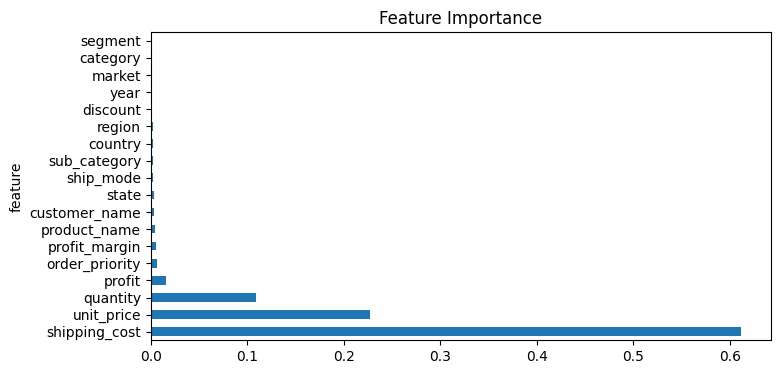

In [201]:
feature_importance_sales.plot(kind="barh", x="feature", y="importance", legend=False, figsize=(8, 4), title="Feature Importance")

## Load Fraud features models and Database

In [202]:
FRAUD_FEATURES = Path.cwd().parent / "app" / "data" / "cleaned" / "X_features_fraud.parquet"
FRAUD_DB = Path.cwd().parent / "app" / "data" / "cleaned" / "fraud_sql_supermarket.parquet"
df_feature_fraud = pd.read_parquet(FRAUD_FEATURES)
df_fraud = pd.read_parquet(FRAUD_DB)
print(f"df_feature_fraud shape: {df_feature_fraud.shape}")
print(f"df_fraud shape: {df_fraud.shape}")

df_feature_fraud shape: (25035, 20)
df_fraud shape: (25035, 26)


In [203]:
df_fraud.head(3)

,id,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin,shipping_days,fraud
0,1,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,0.26,151,0
1,2,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,0.30,212,0
2,3,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,0.45,120,0


## Load Fraud Models

In [204]:
FRAUD_MODELS_PATH = MODELS_DIR / "fraud_ml_models"

# Load fraud models
def load_fraud_models(models_dir: Path):
    models = {}

    for pkl_path in models_dir.glob("*.pkl"):
        model_name = pkl_path.stem.replace("model_", "")
        models[model_name] = joblib.load(pkl_path)

    return models

# Apply
fraud_models = load_fraud_models(FRAUD_MODELS_PATH)
print(f"Load fraud models: {fraud_models.keys()}")

Load fraud models: dict_keys(['GradientBoostingClassifier', 'RandomForestClassifier', 'XGBClassifier'])


## Into X features

In [205]:
X_fraud = df_feature_fraud
print(f"X_fraud shape: {X_fraud.shape}")

X_fraud shape: (25035, 20)


In [206]:
def get_model_features(model):
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "get_booster"):
        try:
            return model.get_booster().feature_names
        except Exception:
            return None        
    if hasattr(model, "feature_importances_"):
        return None  # Feature importances are available, but feature names are not directly accessible
    
    return None 

# Fetch fraud model to X features
def compare_fraud_model_with_X(model, X):
    model_features = get_model_features(model)
    x_features = list(X_fraud.columns)

    print(f"Fraud Model: {type(model).__name__}")
    print(f"X Shape: {X.shape}")

    if model_features is None:
        print("Fraud model feature names are not available.")
        return
    
    print(f"Expected features ({len(model_features)}): {model_features}")
    print(f"X features ({len(x_features)}): {x_features}")

    missing_in_X = [f for f in model_features if f not in x_features]
    extra_in_X = [f for f in x_features if f not in model_features]

    print(f"Missing in X: {missing_in_X}")
    print(f"Extra in X: {extra_in_X}")


for model_name, model in fraud_models.items():
    compare_fraud_model_with_X(model, X_fraud)
    print("-" * 50)

Fraud Model: GradientBoostingClassifier
X Shape: (25035, 20)
Expected features (20): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'unit_price', 'profit_margin', 'shipping_days']
X features (20): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'unit_price', 'profit_margin', 'shipping_days']
Missing in X: []
Extra in X: []
--------------------------------------------------
Fraud Model: RandomForestClassifier
X Shape: (25035, 20)
Expected features (20): ['ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'u

In [207]:
def show_fraud_feature_importance(model, feature_names=None):
    if not hasattr(model, "feature_importances_"):
        return None

    importances = model.feature_importances_

    if feature_names is None:
        feature_names = getattr(model, "feature_names_in_", None)

    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(len(importances))]

    feature_names = list(feature_names)

    if len(feature_names) != len(importances):
        feature_names = feature_names[:len(importances)]

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    return importance_df

feature_importance_fraud = show_fraud_feature_importance(
    fraud_models["XGBClassifier"]
)
feature_importance_fraud

,feature,importance
19,shipping_days,0.817581
18,profit_margin,0.162019
12,discount,0.012674
13,profit,0.004725
11,quantity,0.001351
9,product_name,0.000429
14,shipping_cost,0.000405
10,sales,0.000363
5,market,0.000261
17,unit_price,0.000106


## Implement fraud model on Database

In [208]:
df_fraud_result = df_feature_fraud.copy()

for model_name, model in fraud_models.items():
    fraud_feature_cols = getattr(model, "feature_names_in_", None)

    if fraud_feature_cols is not None:
        X_fraud_2 = df_feature_fraud.reindex(columns=fraud_feature_cols, fill_value=0)
    else:
        X_fraud_2 = df_feature_fraud.copy()

    df_fraud_result[f"{model_name}_pred"] = model.predict(X_fraud_2)

    if hasattr(model, "predict_proba"):
        df_fraud_result[f"{model_name}_score"] = model.predict_proba(X_fraud_2)[:, 1]

    # Add fraud actual column based on the original df_fraud DataFrame
    if "fraud" in df_fraud.columns:
        df_fraud_result["fraud"] = df_fraud["fraud"]

    # Move fraud position into right of the last column
    df_fraud_result = df_fraud_result[[col for col in df_fraud_result.columns if col != "fraud"] + ["fraud"]]

## Implement sales models on Database

In [209]:
df_sales_result = df_model_sales.copy()

for model_name, model in sales_models.items():
    sales_feature_cols = getattr(model, "feature_names_in_", None)

    if sales_feature_cols is not None:
        X_sales_2 = X_sales.reindex(columns=sales_feature_cols, fill_value=0)
    else:
        X_sales_2 = X_sales.copy()

    df_sales_result[f"{model_name}_pred"] = model.predict(X_sales_2)

    # Get models score if available
    if hasattr(model, "predict_proba"):
        df_sales_result[f"{model_name}_score"] = model.predict_proba(X_sales_2)[:, 1]

    # move sales position into right of profit_margin column
    df_sales_result = df_sales_result[[col for col in df_sales_result.columns if col != "sales"] + ["sales"]]

In [213]:
# Fraud data result
df_fraud_result.sample(20)

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin,shipping_days,GradientBoostingClassifier_pred,GradientBoostingClassifier_score,RandomForestClassifier_pred,RandomForestClassifier_score,XGBClassifier_pred,XGBClassifier_score,fraud
21717,2,480,0,257,101,0,11,0,9,1177,470000.0,2,0.25,113100.0,62800.0,3,2014,235000.0,0.24,0,0,4.308310e-10,0,0.003086,0,0.046695,0
14118,2,288,1,457,58,0,11,1,2,3108,1080000.0,3,0.27,-59607.0,187300.0,3,2013,360000.0,-0.06,0,0,5.778834e-10,0,0.000000,0,0.046695,0
6567,1,229,2,588,119,4,10,0,5,1776,5220000.0,5,0.20,-784200.0,640300.0,3,2012,1044000.0,-0.15,-182,1,1.000000e+00,1,0.993333,1,0.911616,1
21416,3,70,0,649,17,5,10,0,5,2422,4460000.0,5,0.00,446000.0,496600.0,3,2014,892000.0,0.10,123,0,4.308310e-10,0,0.000000,0,0.046695,0
16679,3,665,0,581,3,1,0,1,14,3067,960000.0,2,0.00,441600.0,70500.0,3,2014,480000.0,0.46,0,0,4.308310e-10,0,0.010000,0,0.046695,0
7822,3,499,0,421,3,1,0,0,9,1026,410000.0,1,0.00,57300.0,20600.0,1,2012,410000.0,0.14,0,0,4.308310e-10,0,0.010000,0,0.046695,0
10828,3,211,1,352,139,6,10,0,9,1133,400000.0,4,0.00,111776.0,25400.0,3,2013,100000.0,0.28,-333,1,1.000000e+00,1,0.993086,1,0.911616,1
11765,0,400,0,353,121,1,0,2,11,2596,2650000.0,1,0.00,582600.0,433500.0,3,2013,2650000.0,0.22,59,0,4.308310e-10,0,0.002045,0,0.046695,0
5272,3,115,0,375,50,5,3,1,8,2467,130000.0,1,0.00,6400.0,17000.0,2,2012,130000.0,0.05,-213,1,1.000000e+00,1,0.992000,1,0.911616,1
10190,3,648,0,1054,6,0,9,2,13,2378,8780000.0,7,0.10,876750.0,490100.0,3,2013,1254300.0,0.10,123,0,4.308310e-10,0,0.000000,0,0.046695,0


In [212]:
# Sales data result
df_sales_result.sample(20)

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin,LinearRegression_pred,RandomForestRegressor_pred,XGBRegressor_pred,sales
6865,0,327,0,192,139,6,12,2,0,2140,7,0.0,923692.0,771100.0,0,2012,300000.0,0.44,6.852144e+11,6.242055e+06,4989412.0,2100000.0
8332,3,368,0,591,57,0,4,0,4,2809,4,0.0,1569600.0,429700.0,3,2012,1962500.0,0.20,3.486149e+12,6.389615e+06,5915831.5,7850000.0
16948,0,117,0,775,139,6,6,1,2,2657,2,0.2,4768.0,3300.0,3,2014,25000.0,0.10,4.481680e+10,6.414354e+06,4760259.5,50000.0
24072,3,595,0,785,30,5,2,2,6,1686,6,0.0,2353658.4,708500.0,1,2014,960000.0,0.41,1.743094e+12,6.354396e+06,5927343.0,5760000.0
11658,2,150,0,1047,138,4,7,2,11,2598,4,0.0,2128800.0,417700.0,3,2013,1210000.0,0.44,2.118292e+12,6.354396e+06,5889637.5,4840000.0
17094,3,308,1,1045,123,4,7,1,14,2717,2,0.5,-1053900.0,110300.0,3,2014,1055000.0,-0.50,1.960766e+12,6.884150e+06,5951564.5,2110000.0
3280,2,29,0,72,139,6,12,2,13,2628,8,0.2,835128.0,2418600.0,0,2011,927500.0,0.11,2.255881e+12,6.379276e+06,5050499.5,7420000.0
13636,3,380,0,716,139,6,10,2,0,2631,3,0.2,3038040.0,1522000.0,1,2013,2096180.0,0.02,3.932106e+12,6.210684e+06,5730822.0,7754000.0
3654,1,460,0,605,133,3,5,0,5,2785,4,0.6,-599040.0,377000.0,1,2011,352500.0,-0.42,7.650923e+11,6.959494e+06,5826862.0,1410000.0
19216,3,436,1,649,17,5,10,1,14,1110,4,0.0,140000.0,25600.0,3,2014,72500.0,0.48,1.263217e+11,6.353499e+06,5946435.0,290000.0
